# Portfolio loss and importance sampling.

Let $V(S)$ be the value of a portfolio value consisting of
financial instruments based on $m$ market prices $S \in \mathbb{R}^m$. The goal of this project is
to use Monte Carlo to estimate the portfolio loss $L$ over short time periods $\Delta T$. Here, it
is common to use the delta-gamma representation, where the loss is written as
$$
L:=\delta^{\top} \Delta S+(\Delta S)^{\top} \Gamma \Delta S,
$$
where $\delta \in \mathbb{R}^m, \Gamma \in \mathbb{R}^{m \times m}$ and $\Delta S \sim N\left(0,
\Sigma_S\right)$ for some covariance matrix $\Sigma_S$. Sometimes, it is helpful to consider the
linear approximation
$$
Q:=\delta^{\top} \Delta S .
$$
First, assume that $m=1, \delta=2, \Gamma=\Sigma_S=1$, and $x=10$. 
Please always justify your answer.

In [126]:
# setup (only needed once, this cell is hidden in export)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.stats import norm, multivariate_normal, ncx2

## Questions
 

 
> #### Exercise a)
> Write a program to estimate the exceedance probabilities $\mathbb{P}(L>x)$ by crude Monte Carlo simulation.

For a better comparison of our results, we first derive the analytical probability, for the simple case $ m=1, \delta=2$ and $\Gamma=\Sigma_S=1$. 
Using these parameters we can write:
$$
\mathbb{P}(L > x) = \mathbb{P}(2Z + Z^2 >x) \quad Z \sim N(0,1)
$$
Completing the square we get $2Z + Z^2 =(Z+1)^2-1= Y^2 - 1$ where $Y \sim X^2_{nc}(\nu = 1, \lambda = 1)$, and where $X^2_{nc}(\nu, \lambda)$ denotes a non-central chi-square distribution with $\nu$ degrees of freedom and non-centrality parameter $\lambda$. In particular the analytical probability is can be calulated by:
$$
\mathbb{P}(L > x) = 1 - \mathbb{P}(Y^2 -1 \le x ) = 1 - \mathbb{P}(Y^2 \le x +1)
$$
This is determined to be

In [127]:
x = 10
analytical_prop = 1-ncx2.cdf(x+1, df=1, nc=1)
print(f"Analytical probability P(L > {x}): {analytical_prop:.6f}")

Analytical probability P(L > 10): 0.010270


We now implement a crude Monte Carlo simulation, of this probability. We first define:

In [128]:
np.random.seed(2)  # for reproducibility
# assumptions
m = 1
delta = 2
gamma = 1
sigma = np.array([[1]])  # covariance matrix


def loss(m, delta, delta_S, gamma):
    """ Compute the loss L given delta, gamma, sigma and delta_S, note that all parameters shold be of dimension m."""
    if m == 1:
        Q = delta*delta_S
        L = Q + (delta_S * gamma) * delta_S
    else:
        Q = delta_S@delta
        L = Q + np.sum((delta_S @ gamma) * delta_S, axis=1)
    return L

Crude Monte Carlo is then done by finding $N$ realizations of $\Delta S \sim N(0,1)$. For each realization we then determine the *empirical* loss $\tilde L$ and weather or not $\tilde L < x$. In particular the Law of large numbers then gives that
$$
\frac{\mathbf{1}_{ L_1 < x} + \ldots +  \mathbf{1}_{ L_N < x} }{N} \underset{N \to \infty}{\longrightarrow}\mathbb{E}[\mathbf{1}_{ L_1 < x}] = \mathbb{P}(L_1 < x) = 0.010270
$$
In other words, crude Monte Carlo will converge towards the analytical probability when we increase our sample size parameter $N$. 

For $N=10^6$ we find:

In [129]:
N = 10**6  # number of simulations


def crude_monte_carlo(N, m, delta, gamma, sigma, x, loss_function):
    """ Crude Monte Carlo simulation of the probability P(L > x), note that all parameters shold be of dimension m."""

    delta_S = np.random.multivariate_normal(np.zeros(m), sigma, size=N)
    L = loss_function(m, delta, delta_S, gamma)
    return np.mean(L > x), L


P_crude, L = crude_monte_carlo(N, m, delta, gamma, sigma, x, loss)
Z = (L > x).astype(float)
SE = np.std(Z, ddof=1) / np.sqrt(N)
print(f"Crude Monte Carlo estimate of P(L > {x}): {P_crude:.6f}")
print(f"Difference to analytical: {abs(P_crude - analytical_prop):.6f}")
print(f"SE: {SE}")

Crude Monte Carlo estimate of P(L > 10): 0.010188
Difference to analytical: 0.000082
SE: 0.00010042019089911518


Which is already a quite small deviation, however for smaller $N$ we find:

In [130]:
N = 100
P_crude_small, L_small = crude_monte_carlo(N, m, delta, gamma, sigma, x, loss)
print(
    f"Crude Monte Carlo estimate of P(L > {x}) with N={N}: {P_crude_small:.6f}")
print(f"Difference to analytical: {abs(P_crude_small - analytical_prop):.6f}")

Crude Monte Carlo estimate of P(L > 10) with N=100: 0.000000
Difference to analytical: 0.010270


By the above, it is clear that our crude monte carlo estimate very much depends on the value of $N$. 

> #### Exercise b)
>  Use control variables method to reduce the variance of the estimator from part (a).  Discuss several possibilities and argue for your final choice.  Would you recommend to use these methods given potential longer compute time?

In our Monte Carlo simulation, we want to determine $\mathbb{P}(L < x) = \mathbb{E}[\mathbf{1}_{L < x}] =: \ell$. We know that this can be done naively by the crude Monte Carlo utilizing the Law of Large numbers. However, if we want a high precision of the estimate, we might need a very high sample size $N$. Another way to determine the quality of our estimates, compared to the absoulte difference in numerical value above, is the mean-squared error. For a given set of samples $Y_1,\ldots,Y_n$ from the crude Monte Carlo  we have:
$$
\mathbb{E}\left[\left(\frac{(Y_1 + \ldots + Y_n)}{N} - \mathbb{E}[Y_1]\right)^2\right] = \mathbb{V}\left[\frac{(Y_1 + \ldots + Y_n)}{N}\right] = \frac{1}{N}\mathbb{V}[Y_1].
$$
The control variables method is one way to guarentee a variance reduction and thus increase the quality of our estimate of $\ell$, at least by the above measure of quality. The main idea is that apart from sampling variables of the form $Y = \mathbf{1}_{L < x}$ as in the crude Monte Carlo, we also calculate $Z$, where $\mathbb{E}[Z]$ is known, and where $Y$ and $Z$ are positively correlated. We then use $\hat Y = Y - (Z - \mathbb{E}[Z])$ as our new variable for the Law of large numbers, indeed:
$$
\mathbb{E}[\hat Y] = \mathbb{E}[Y] - 0 = \ell
$$
 In particular, we have shown in the lectures, that for the class of estimators given by
$$
\hat\ell := \frac{1}{N} \sum_{i \leq N}\left[Y-\beta\left(Z_i-\ell_Z\right)\right]
$$
there exists an optimal $\beta$ given by
$$
\beta_{\mathrm{opt}}=\frac{\mathrm{Cov}[Y, Z]}{\mathbb{V}(Z)}
$$
and the minimum value of the variance is
$$
\frac{1}{N} \mathbb{V}(Y)\left(1-\mathrm{Corr}[Y, Z]^2\right)
$$
By the above, the a variance reduction is then guarenteed since $Y$ and $Z$ was assumed to be positivly correlated.

To implement this method we will use the proposed estimator $Q$ stated in the project description, and consider $\mathbf{1}_{Q > (x/2)}$

In [131]:
def cv_estimator(Z, x, delta, m, analytical_mean):
    if m == 1:
        H = delta*Z
    else:
        H = Z@delta

    return H > x/2, np.mean(H > x/2)

In particular, for the given parameters, we have $\mathbb{E}[\mathbf{1}_{Q > (x/2)}] = \mathbb{P}[2\Delta S \ge x/2] = 1-\phi(x/4)$, where $\Delta S\sim N(0,1)$ 

We can then implement Control variance for this estimator:

Optimal beta: 0.9959
Control Variance using Q in Monte Carlo estimate of P(L > 10): 0.010085
Variance reduction: 2.46 times


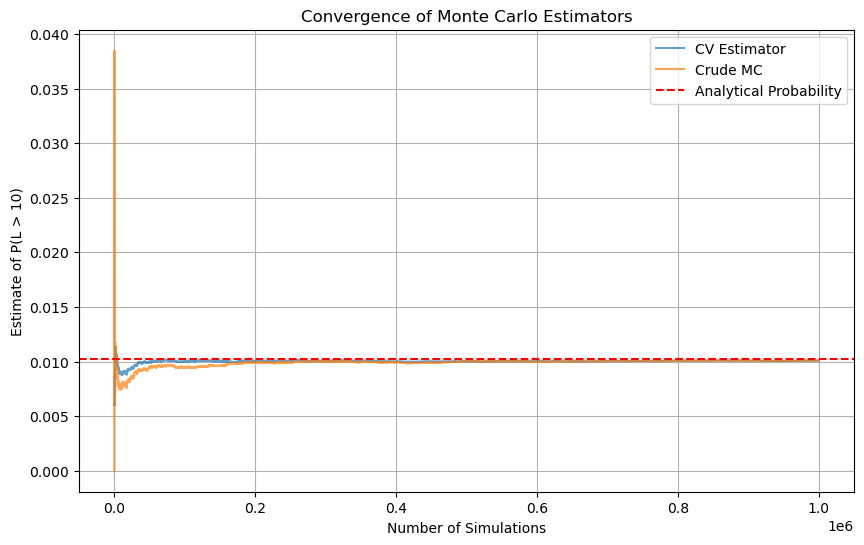

In [132]:
N = 10**6


def control_variance_monte_carlo(N, m, delta, x, control_variance_estimator, analytical_mean):
    """ Control Variance monte carlo of P(L>x), note that all parameters shold be of dimension m."""

    Z = np.random.multivariate_normal(np.zeros(m), sigma, N)
    Y = loss(m, delta, Z, gamma) > x
    H, l_H = control_variance_estimator(Z, x, delta, m, analytical_mean)

    model = LinearRegression()
    beta = model.fit(H.reshape(-1, 1), Y).coef_[0]

    print(f"Optimal beta: {beta.item():.4f}")

    Y_hat = Y - beta*(H - l_H)

    return np.mean(Y_hat), Y, Y_hat


P_cv, Y, Y_hat = control_variance_monte_carlo(
    N, m, delta, x, cv_estimator, norm.cdf(x/4))
print(
    f"Control Variance using Q in Monte Carlo estimate of P(L > {x}): {P_cv:.6f}")
print(f"Variance reduction: {np.var(Y)/np.var(Y_hat):.2f} times")


# create a plot of the convergence of the probability estimates
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(Y_hat)/np.arange(1, N+1),
         label='CV Estimator', alpha=0.7)
plt.plot(np.cumsum(Y)/np.arange(1, N+1), label='Crude MC', alpha=0.7)
plt.axhline(analytical_prop, color='red', linestyle='--',
            label='Analytical Probability')
plt.xlabel('Number of Simulations')
plt.ylabel(f'Estimate of P(L > {x})')
plt.title('Convergence of Monte Carlo Estimators')
plt.legend()
plt.grid()
plt.show()

> #### Exercise c)
> Design an importance-sampling method to reduce the variance of the estimator from part (a). Again, discuss several options and argue for your final choice. Again, discuss the trade-off between additional compute time and variance reduction.

In importance sampling we want to find another density, which will give more information from each simulated value. In other words we want to find a density $g$, where the event $L > 10$ is more likely.

Let's start by computing the points $x$, fulfilling $L>10$:
$$L=x^2 + 2x > 10$$
$$\Leftrightarrow x^2 + 2x + 1 > 11$$
$$\Leftrightarrow x+1 > \sqrt{11}, \quad  x+1 < - \sqrt{11}$$
$$\Leftrightarrow x_1 > 2.3166, \quad x_2 < -4.3166$$
This means, that
$$\mathbb{P} (L > 10) = \mathbb{P} ((\Delta S)^2 + 2 \Delta S > 10) = \mathbb{P} (\Delta S < -4.3166) + \mathbb{P} (\Delta S > 2.3166)$$

Now it is worth noticing that since $\Delta S \sim N(0,1)$, then
$$\mathbb{P} (\Delta S > 2.3166) = 1 - \Phi (2.3166) = 0.01022$$
$$\mathbb{P} (\Delta S < -4.3166) = \Phi (-4.3166) = 0.0000085$$
Which means that almost all of the contribution to $\mathbb{P} (L > 10)$ comes from $\Delta S > 2.3166$, i.e. the upper tail. 
Therefore, it wouldn't make much sense to do Importance Sampling (exponential tiliting), where we set $x = -4.3166$.
Now it is left to either do Importance Sampling (exponential tilting) with respect to $x = 2.3166$ or a mixture of the two. But, since the contribution of $(\Delta S < -4.3166)$ is that minor, a mixture would probably only result in more wasted samples.

Thus, we will only do importance sampling where we shift the distribution of $\Delta S$ to collect the effect of $\Delta S > 2.3166$.

This we will do by exponential tilting.

Therefore, let $x = \sqrt{11} - 1$ and we compute the optimal $\theta$ as the one fulfilling
$$\kappa^{\prime} (\theta) = x$$
where $\kappa^{\prime} (\theta)$ is given as the following, as $\Delta S \sim N(0, 1)$
$$\kappa^{\prime} (\theta) = \mu + \sigma^2 \cdot \theta = \theta = \mathbb{E}_{\theta} [\Delta S]$$
Solving for $\theta$ gives
$$\theta = x$$

In the following we will use this $\kappa (\theta)$ (again as $\Delta S \sim N(0,1)$):
$$\kappa(\theta) = \mu \cdot \theta + 0.5 \cdot \sigma^2 \cdot \theta^2 = 0 \cdot x + 0.5 \cdot 1^2 \cdot x^2 = 0.5 \theta^2 $$
And weights:
$$e^{- \theta \cdot \Delta S + \kappa (\theta)}$$

In [133]:
np.random.seed(2)  # for reproducibility

# assumptions
N = 10**6
mu = 0
delta = 2
gamma = 1
sigma = 1  # covariance matrix

x = np.sqrt(11) - 1

def IS_simulation(N, mu, delta, gamma, sigma, x):
    # Actually theta = x, but to be able to use for all values of mu and sigma we write it like this
    theta = (x - mu) / (sigma**2)

    mu_tilted = mu + theta *(sigma**2)
    delta_S_tilted = np.random.normal(mu_tilted, sigma, size=N)

    L_tilted = delta_S_tilted**2 * gamma + delta * delta_S_tilted
    Z = (L_tilted > 10).astype(float)

    kappa = 0.5 * (theta**2)
    weights = np.exp(- theta * delta_S_tilted + kappa)

    weighted_Z = Z * weights
    running_estimate = np.cumsum(weighted_Z) / np.arange(1, N + 1)

    estimator = running_estimate[-1]
    se = np.std(weighted_Z, ddof=1) / np.sqrt(N)

    return estimator, se, running_estimate


In [134]:
# Exponential tilting with x=2.3166
p_est_1, se_1, running_estimate_1 = IS_simulation(N, mu, delta, gamma, sigma, x)
print(f"IS estimate for shift with x={x:.6f}: p_hat = {p_est_1:.6f}, SE_hat = {se_1:.6f}")



IS estimate for shift with x=2.316625: p_hat = 0.010286, SE_hat = 0.000017


To emphasize that importance sampling where we shift $\Delta S$ to $N(-4.3166, 1)$ is not as effective, we consider the follwing:

In [135]:
x_2 = - np.sqrt(11) - 1
p_est_2, se_2, running_estimate_2 = IS_simulation(N, mu, delta, gamma, sigma, x_2)
print(f"IS estimate for shift with x={x_2:.6f}: p_hat = {p_est_2:.6f}, SE_hat = {se_2:.6f}")


IS estimate for shift with x=-4.316625: p_hat = 0.000008, SE_hat = 0.000000


Where it can clearly be seen, that we do not get an exceedance probability close to the theoretical exceedance probability.

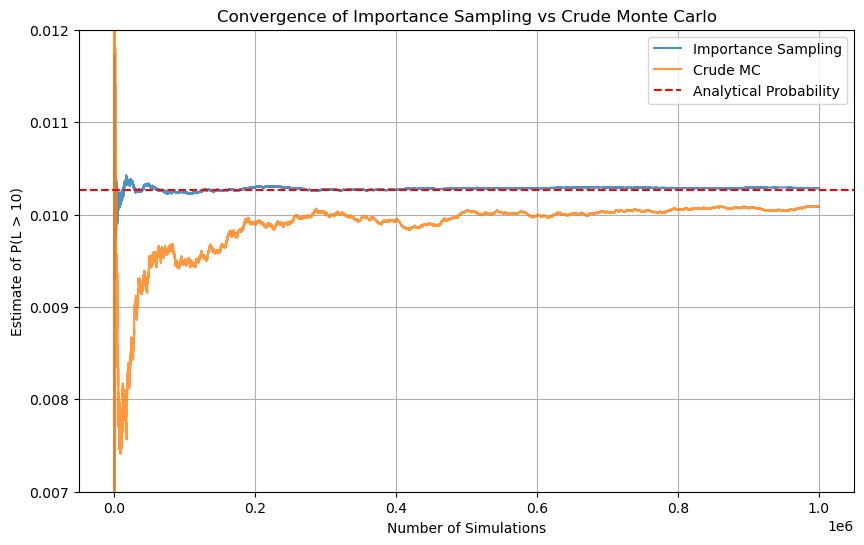

Analytical P(L>10) = 0.01027001
IS Estimate = 0.01028609


In [139]:
# Plot convergence
plt.figure(figsize=(10, 6))
plt.plot(running_estimate_1, label='Importance Sampling', alpha=0.8)
plt.plot(np.cumsum(Y)/np.arange(1, N+1), label='Crude MC', alpha=0.8)
plt.axhline(analytical_prop, color='red', linestyle='--', label='Analytical Probability')

plt.xlabel('Number of Simulations')
plt.ylabel(f'Estimate of P(L > 10)')
plt.title('Convergence of Importance Sampling vs Crude Monte Carlo')
plt.legend()
plt.grid(True)

plt.ylim(0.007, 0.012)

plt.show()

print(f"Analytical P(L>10) = {analytical_prop:.8f}")
print(f"IS Estimate = {p_est_1:.8f}")

> #### Exercise d)
>  Create and discuss visualizations for comparing (a), (b) and (c).

> #### Exercise e)
> Show that for the specific choices of $m, \delta, \Gamma$ and $\Sigma_S$, the probability $\mathbb{P}(L>x)$ has a closed-form expression only involving the cdf of the standard normal distribution. Is this still true when choosing another distribution? For the variance-reduction methods in (b), (c), how easy do they generalize when $L$ is replaced by another relevant distribution?

> #### Question 1)
> Now, assume that $m=2, \delta=(2,2)^{\top}, \Gamma=I d_2, \Sigma_S=\left(\begin{array}{cc}1 & 0.5 \\ 0.5 & 1\end{array}\right)$, and $x=15$. Repeat parts (a) and (b) for these new parameters.

Crude Monte Carlo estimate of P(L > 15): 0.016550
Optimal beta: 0.9539
Control Variance using Q in Monte Carlo estimate of P(L > 15): 0.015710
Variance reduction: 8.28 times


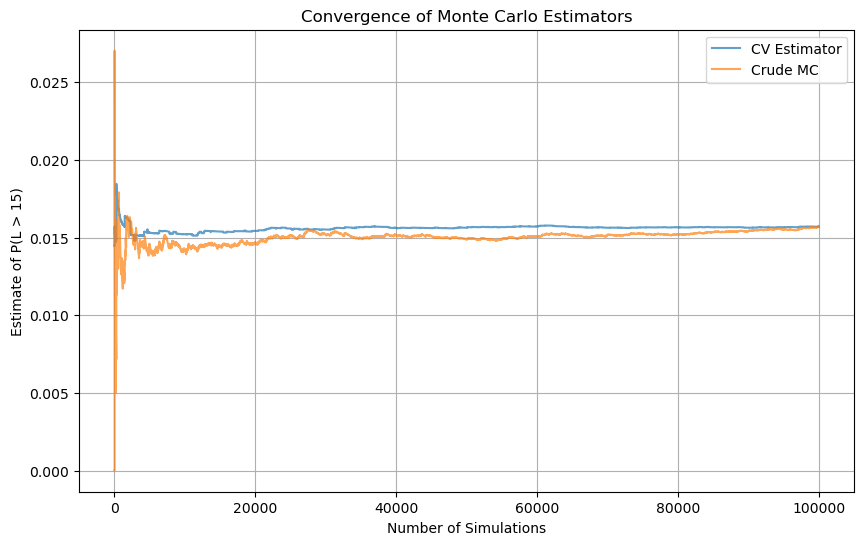

In [10]:
m = 2
delta = np.array([2, 2])
gamma = np.identity(2)
sigma = np.array([[1, 0.5], [0.5, 1]])
x = 15
N = 10**5


P_crude, L = crude_monte_carlo(N, m, delta, gamma, sigma, x, loss)
print(f"Crude Monte Carlo estimate of P(L > {x}): {P_crude:.6f}")

P_cv, Y, Y_hat = control_variance_monte_carlo(
    N, m, delta, x, cv_estimator, 0.5)
print(
    f"Control Variance using Q in Monte Carlo estimate of P(L > {x}): {P_cv:.6f}")
print(f"Variance reduction: {np.var(Y)/np.var(Y_hat):.2f} times")

# create a plot of the convergence of the probability estimates
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(Y_hat)/np.arange(1, N+1),
         label='CV Estimator', alpha=0.7)
plt.plot(np.cumsum(Y)/np.arange(1, N+1), label='Crude MC', alpha=0.7)

plt.xlabel('Number of Simulations')
plt.ylabel(f'Estimate of P(L > {x})')
plt.title('Convergence of Monte Carlo Estimators')
plt.legend()
plt.grid()
plt.show()

> #### Exercise f)
> Now, use the Cholesky decomposition to find a matrix $\widetilde{C}$ such that $\Delta S=\widetilde{C} Z$ where $Z \sim N\left(0, I_2\right)$. Next, find an orthogonal matrix $U$ and a diagonal matrix $\Lambda=\operatorname{diag}\left(\lambda_1, \lambda_2\right)$ such that $\widetilde{C}^{\top} \widetilde{C}=U \Lambda U^{\top}$. Show that the loss $L$ can be expressed as $$ L=b_1 Z_1+b_2 Z_2+\lambda_1 Z_1^2+\lambda_2 Z_2^2 $$ where $b=C^{\top} \delta$ with $C=\widetilde{C} U$.

> #### Exercise g)
> Similarly as in part (c), use $\prod_{i \leq 2} \exp \left(\theta_i Z_i-\psi^*\left(\theta_i\right)\right)$ as an importance-sampling density, where $\psi^*$ is the cumulant generating function of a standard normal distribution. Experiment with different parameters $\theta_i$.

> #### Exercise h)
> For $\left(\lambda_1 \vee \lambda_2\right) \theta<1 / 2$ show that $$\psi_L(\theta):=\log \mathbb{E}[\exp (\theta L)]=\frac{1}{2} \sum_{j \leq 2}\left(\frac{\theta^2 b_j^2}{1-2 \theta \lambda_j}-\log \left(1-2 \theta \lambda_j\right)\right) .$$ You may use without proof that $$\mathbb{E}\left[\exp \left(\theta\left(Z_1+c\right)^2\right)\right]=(1-2 \theta)^{-1 / 2} \exp \left(\theta c^2 /(1-2 \theta)\right)$$ holds for all $c \in \mathbb{R}$ and $\theta<1 / 2$.

> #### Exercise i)
> Use part (h) to develop an importance-sampling algorithm for the estimation of $\mathbb{P}(L>15)$. Develop a heuristic for choosing $\theta$.

> #### Exercise j)
> Describe broadly how stratified sampling could be used for simulating $L$ when the random variable $Q$ is used for stratification. For this question, a description of your approach is sufficient; you do not need to implement a simulation program.